In [1]:
import pandas as pd
import numpy as np
import multiprocessing as mp
import matplotlib.pyplot as plt

from catomatic.BinaryCatalogue import BinaryBuilder

from protocols import utils, functions

plt.rcParams['figure.dpi'] = 200
plt.rcParams['font.family'] = 'Helvetica'  
plt.rcParams['font.size'] =7 
plt.rcParams['figure.figsize'] = (6.69, 5.02)

%load_ext autoreload
%autoreload 2

In [2]:
# the path to the CRyPTIC v3.1.0 data tables (including the DST_MEASUREMENTS_+.pkl which has DST for the validation samples appended)
cryptic_tables_path = '/Users/fowler/Dropbox/files/cryptic/cryptic-release-three/cryptic-tables-v3.1.0/'

# whether to run the processes which take a long time
run_long_processes = False

# number of cores
n_cores = 6

drug_genes = {
    'BDQ': {"genes": ["Rv0678", "atpE", "pepQ"], "phylogenetic": []},
    'CFZ': {"genes": ["Rv0678", "atpE", "pepQ"], "phylogenetic": []},
    "AMI": {"genes": ["eis", "rrs"], "phylogenetic": []},
    "CAP": {"genes": ["rrs", "tlyA"], "phylogenetic": []},
    "DLM": {"genes": ["ddn"], "phylogenetic": []},
    "EMB": {"genes": ["embA", "embB"], "phylogenetic": []},
    "ETH": {"genes": ["ethA", "fabG1", "inhA"], "phylogenetic": []},
    "INH": {"genes": ["katG", "inhA", "ahpC", "fabG1"], "phylogenetic": []},
    "KAN": {"genes": ["eis", "rrs"], "phylogenetic": []},
    "LEV": {"genes": ["gyrA", "gyrB"], "phylogenetic": ['gyrA@S95T']},
    "LZD": {"genes": ["rplC"], "phylogenetic": []},
    "MXF": {"genes": ["gyrA", "gyrB"], "phylogenetic": ['gyrA@S95T']},
    "RIF": {"genes": ["rpoB"], "phylogenetic": []},
    "STM": {"genes": ["gid", "rpsL", "rrs"], "phylogenetic": []},
    'PZA': {"genes": ["pncA"], "phylogenetic": []},    
}

In [3]:
opt_cats_v1 = pd.read_csv('results/grid_search/opt_cats_v1.csv')
opt_cats_v1

,DRUG,BACKGROUND_RATE,p_value,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,Score,R,S,U,Total,catalogue
0,RIF,0.25,0.9,0.963381,0.984365,0.971158,0.940540,0.984850,0.971232,41,25,347,413,catomatic_v1
1,INH,0.25,0.9,0.944380,0.988292,0.956512,0.915997,0.988895,0.959980,60,23,617,700,catomatic_v1
2,STM,0.20,0.9,0.954789,0.934732,0.911294,0.883635,0.940957,0.940073,89,12,509,610,catomatic_v1
3,EMB,0.25,0.9,0.952322,0.914556,0.906068,0.873186,0.922754,0.931741,17,53,1029,1099,catomatic_v1
4,PZA,0.05,0.9,0.884048,0.973402,0.974673,0.874152,0.974137,0.928979,417,1,157,575,catomatic_v1
5,LEV,0.20,0.9,0.922835,0.967359,0.880529,0.882075,0.971803,0.927731,14,15,317,346,catomatic_v1
6,MXF,0.25,0.9,0.943130,0.928090,0.868136,0.907238,0.938974,0.923619,11,18,383,412,catomatic_v1
7,AMI,0.05,0.9,0.848526,0.982960,0.922512,0.825884,0.984354,0.903654,14,8,387,409,catomatic_v1
8,CAP,0.05,0.9,0.844141,0.975157,0.920088,0.811816,0.977242,0.898635,43,4,232,279,catomatic_v1
9,ETH,0.05,0.9,0.913028,0.862800,0.914050,0.879388,0.876170,0.898164,295,4,358,657,catomatic_v1


In [4]:
build_frs_values = np.arange(0.1, 1.0, 0.1)
test_frs_values = np.arange(0.1, 1.0, 0.1)

# Shared memory dictionaries for storing results
manager = mp.Manager()
sensitivity_matrix = manager.dict()
specificity_matrix = manager.dict()
coverage_matrix = manager.dict()
sensitivity2_matrix = manager.dict()
specificity2_matrix = manager.dict()

def process_drug_frs(drug):

    mutations = functions.prep_mutations('data/mutations-v3.1.0/', 
                                    drug_genes[drug]['genes'], 
                                    version='v3.1.0', 
                                    mut_path=cryptic_tables_path+'MUTATIONS.parquet', 
                                    var_path=cryptic_tables_path+'VARIANTS.parquet', 
                                    train=True)
    
    test_mutations = functions.prep_mutations('data/mutations-v3.1.0/', 
                                    drug_genes[drug]['genes'], 
                                    version='v3.1.0', 
                                    mut_path=cryptic_tables_path+'MUTATIONS.parquet', 
                                    var_path=cryptic_tables_path+'VARIANTS.parquet', 
                                    train=False)
    
    phenotypes = functions.prep_phenotypes(
        drug,
        cryptic_tables_path+"DST_MEASUREMENTS_+.pkl",
        cryptic_tables_path+"GENOMES.parquet",
        cryptic_tables_path+"WGS_SAMPLES.parquet",
        'v1.0'
    )
    
    background, p = opt_cats_v1.loc[opt_cats_v1.DRUG == drug, ['BACKGROUND_RATE', 'p_value']].iloc[0]
    sens_results, spec_results, cov_results, sens2_results, spec2_results = {}, {}, {}, {}, {}
    
    for build_FRS in build_frs_values:

        catfile = f"./catalogues/cryptic-v1/frs/{drug.lower()}/bg_{background}_p_{p}_FRS_{np.round(build_FRS,1)}.csv"
        #if not os.path.exists(catfile):
        catalogue = BinaryBuilder(samples=phenotypes, mutations=mutations, FRS=build_FRS, seed=drug_genes[drug]['phylogenetic']).build(
            test='Binomial', background=background, strict_unlock=True, p=p
        )
        print(f'{drug}-{background}-{p}-{np.round(build_FRS, 1)}')
        catalogue.to_piezo(
            genbank_ref='NC00962.3',
            catalogue_name=f'{drug}-{background}-{p}-{np.round(build_FRS, 1)}',
            version='0.0',
            drug=drug,
            wildcards=f"./data/wildcards/{drug.lower()}_wildcards.json",
            json_dumps=True,
            outfile=catfile
        )
            
        sens_results[build_FRS], spec_results[build_FRS], cov_results[build_FRS] = {}, {}, {}
        
        for test_FRS in test_frs_values:
            all_data = pd.merge(
                phenotypes, 
                test_mutations[test_mutations.FRS >= test_FRS], 
                on=['UNIQUEID'], 
                how='left'
            )
            _, cov, sens, spec, sens2, spec2 = utils.piezo_predict(iso_df=all_data, drug=drug, catalogue_file=catfile)
            sens_results[build_FRS][test_FRS] = sens * 100
            spec_results[build_FRS][test_FRS] = spec * 100
            cov_results[build_FRS][test_FRS] = cov * 100
            sens2_results[build_FRS][test_FRS] = sens2 * 100
            spec2_results[build_FRS][test_FRS] = spec2 * 100

    sensitivity_matrix[drug] = sens_results
    specificity_matrix[drug] = spec_results
    coverage_matrix[drug] = cov_results
    sensitivity2_matrix[drug] = sens2_results
    specificity2_matrix[drug] = spec2_results

def convert_to_dataframe(matrix, metric):

    data = []
    
    for drug, builds in matrix.items():
        for build, tests in builds.items():
            for test, value in tests.items():
                data.append([drug, build, test, value])

    df = pd.DataFrame(data, columns=['Drug', 'Build_FRS', 'Test_FRS', metric])

    df.set_index(['Drug', 'Build_FRS', 'Test_FRS'], inplace=True)

    return df



In [5]:
# Parallel execution
if run_long_processes:

    mp.set_start_method('fork', force=True)
    with mp.Pool(mp.cpu_count() - 1) as pool:
        pool.map(process_drug_frs, opt_cats_v1['DRUG'])

    sensitivity_df = convert_to_dataframe(sensitivity_matrix, 'Sensitivity')
    specificity_df = convert_to_dataframe(specificity_matrix, 'Specificity')
    coverage_df = convert_to_dataframe(coverage_matrix, 'Coverage')
    sensitivity2_df = convert_to_dataframe(sensitivity2_matrix, 'Sensitivity')
    specificity2_df = convert_to_dataframe(specificity2_matrix, 'Specificity')

    perf_df = sensitivity_df.join(specificity_df).join(coverage_df).join(sensitivity2_df).join(specificity2_df)

    perf_df.to_csv('results/frs/v1_perf.csv',index=True)

else:
    
    perf_df = pd.read_csv('results/frs/v1_perf.csv')

perf_df



,Unnamed: 0,Drug,Build_FRS,Test_FRS,Sensitivity,Specificity,Coverage
0,0,AMI,0.1,0.1,84.852639,98.296014,92.251211
1,1,AMI,0.1,0.2,84.235778,98.335074,92.360569
2,2,AMI,0.1,0.3,83.618917,98.404223,92.443889
3,3,AMI,0.1,0.4,83.127572,98.435871,92.490757
4,4,AMI,0.1,0.5,82.680412,98.454841,92.506379
...,...,...,...,...,...,...,...
1048,1048,INH,0.9,0.5,93.775613,98.921389,95.853207
1049,1049,INH,0.9,0.6,93.601236,98.930960,95.881264
1050,1050,INH,0.9,0.7,93.372982,98.935870,95.912126
1051,1051,INH,0.9,0.8,93.134075,98.955147,95.940183


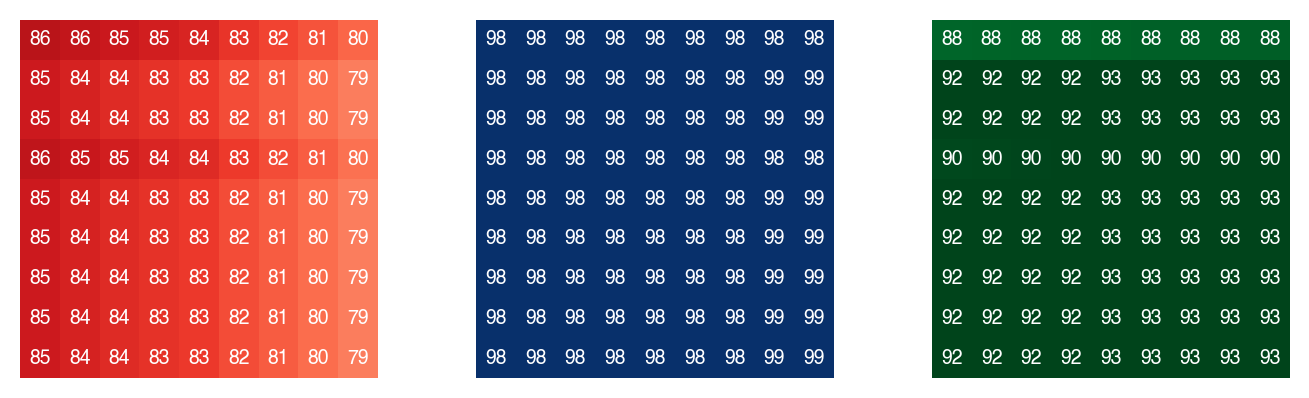

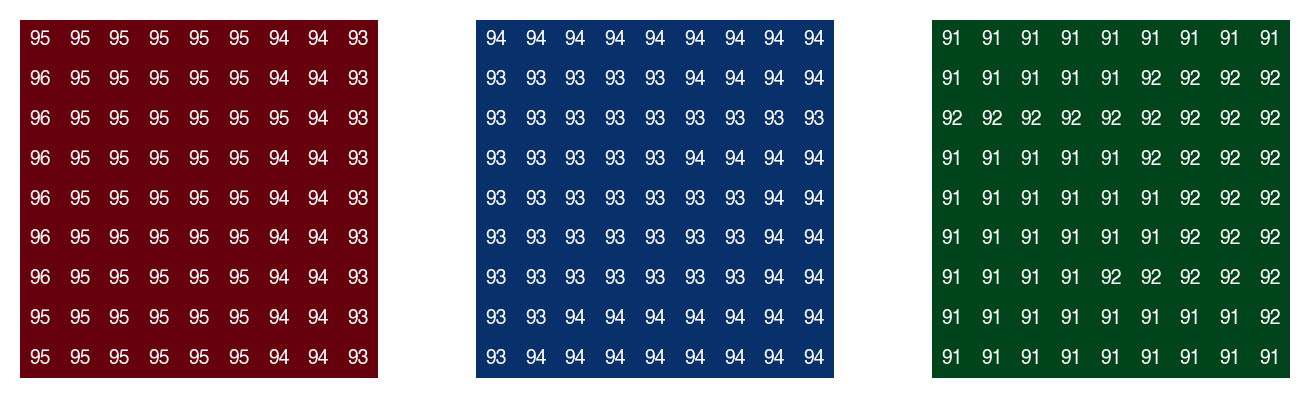

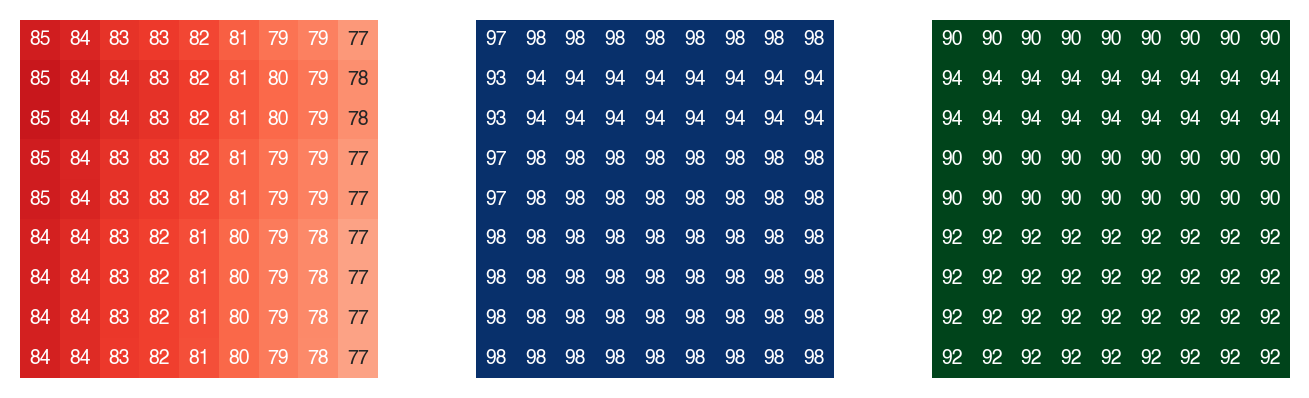

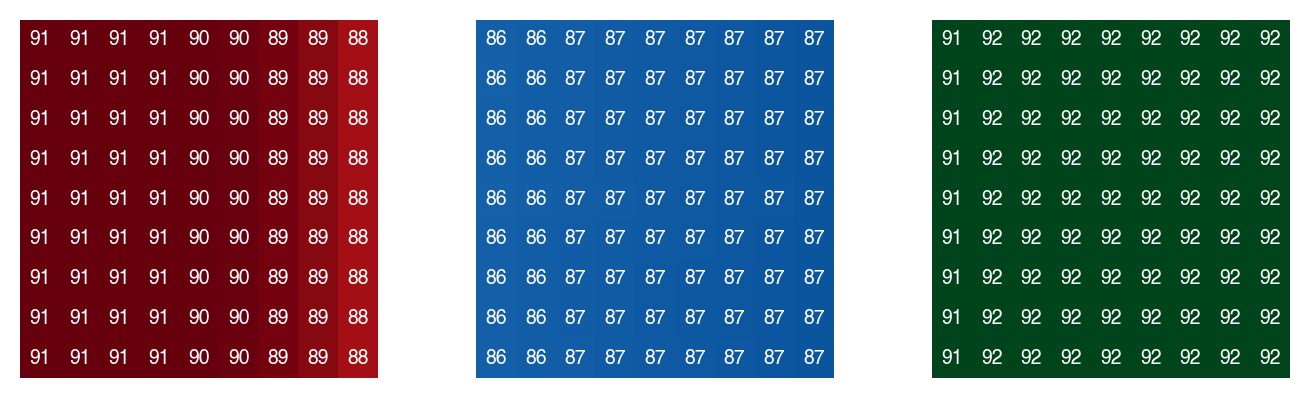

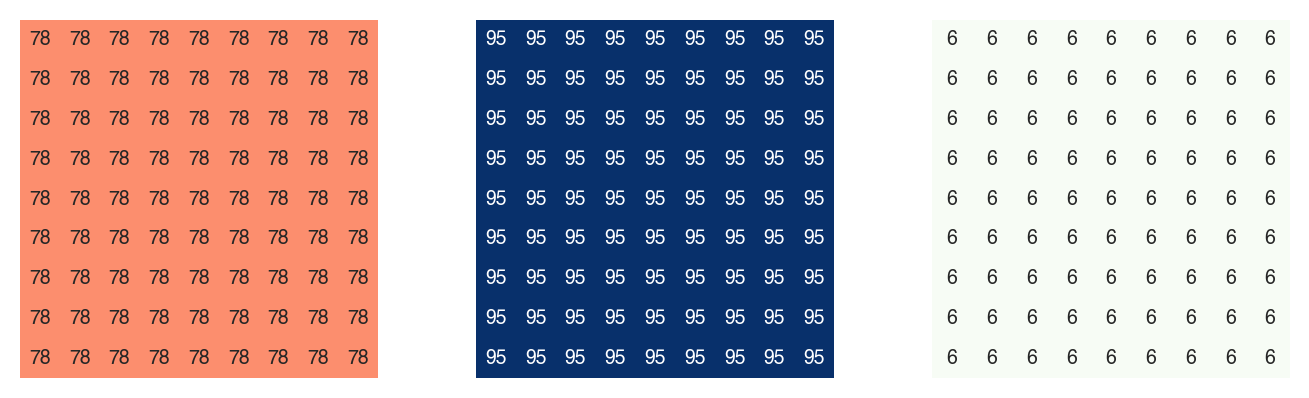

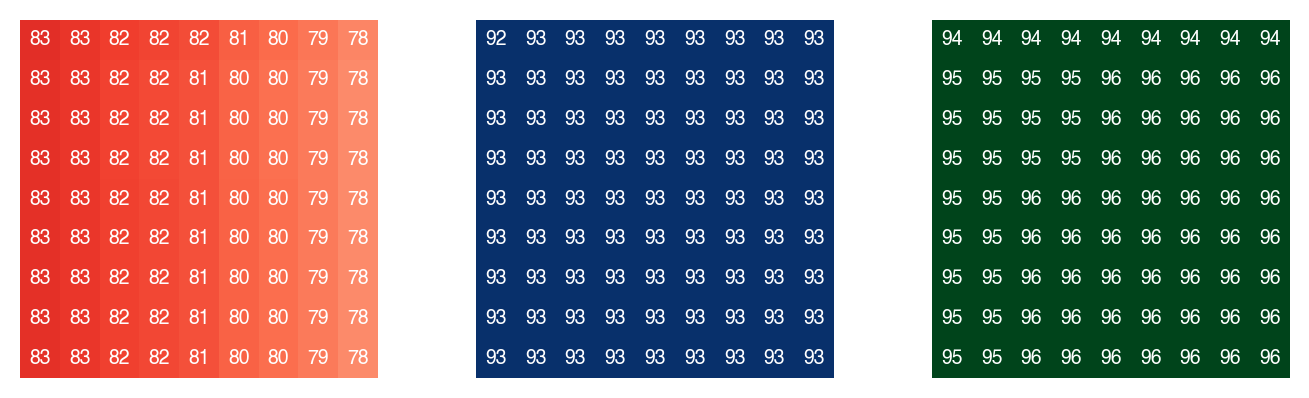

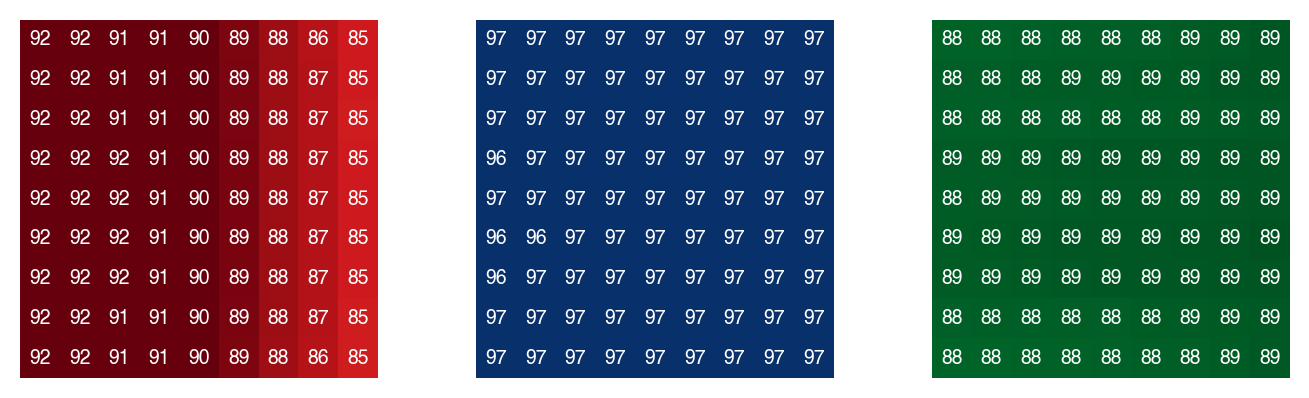

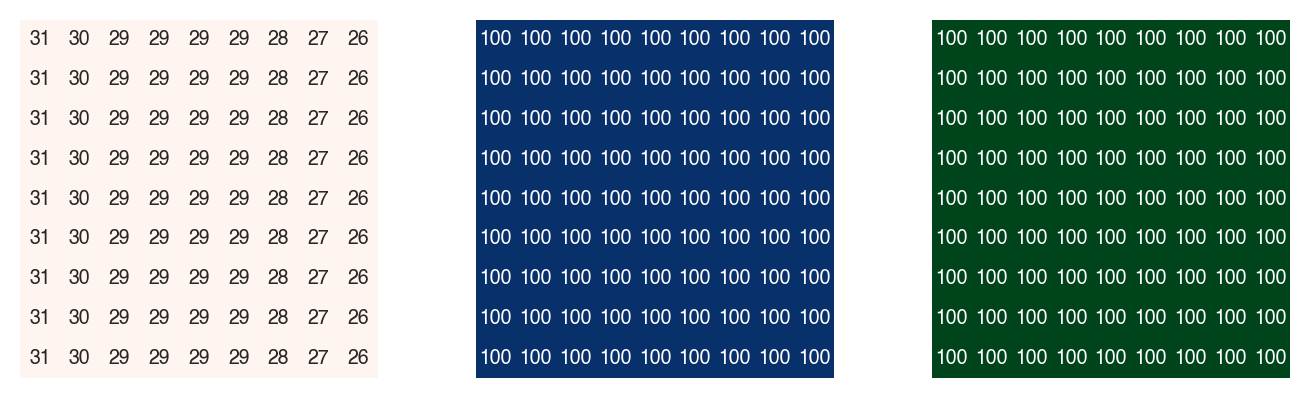

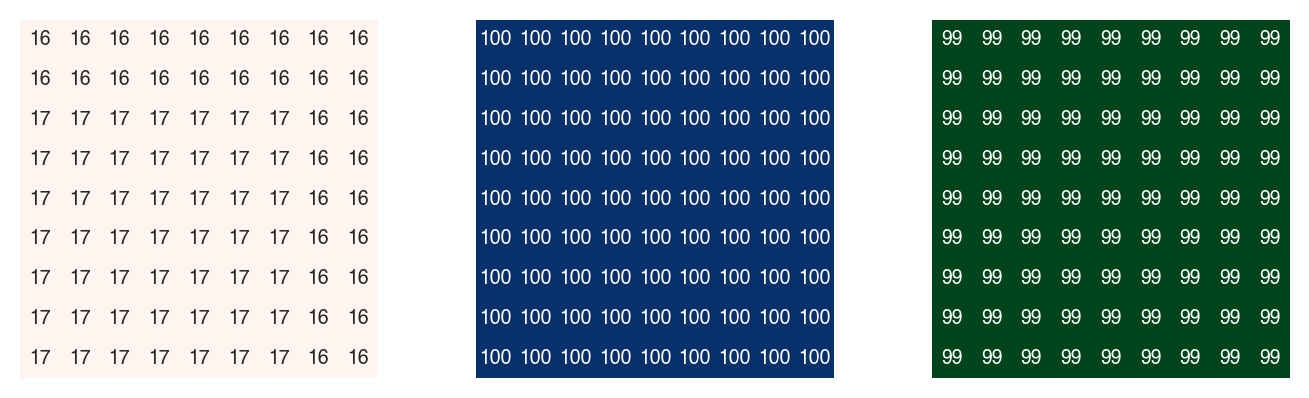

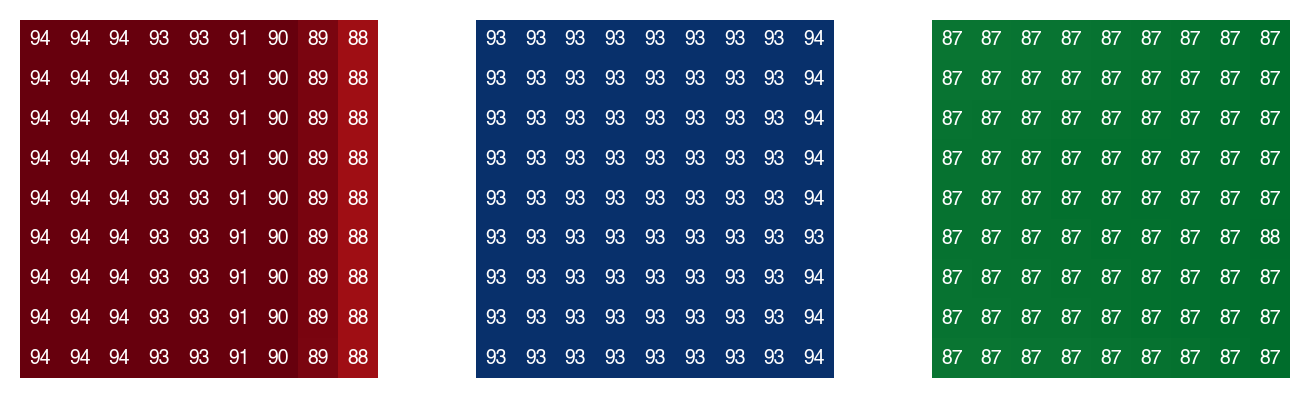

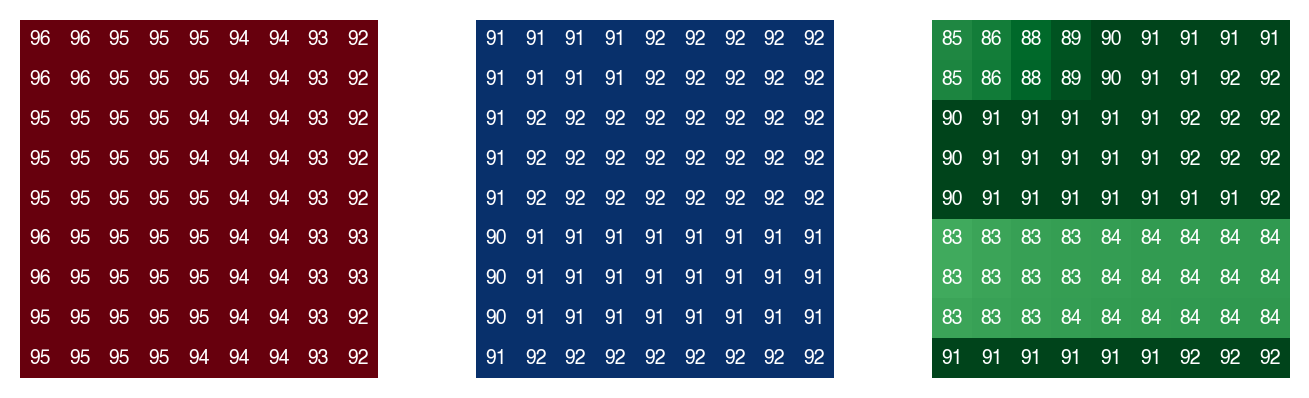

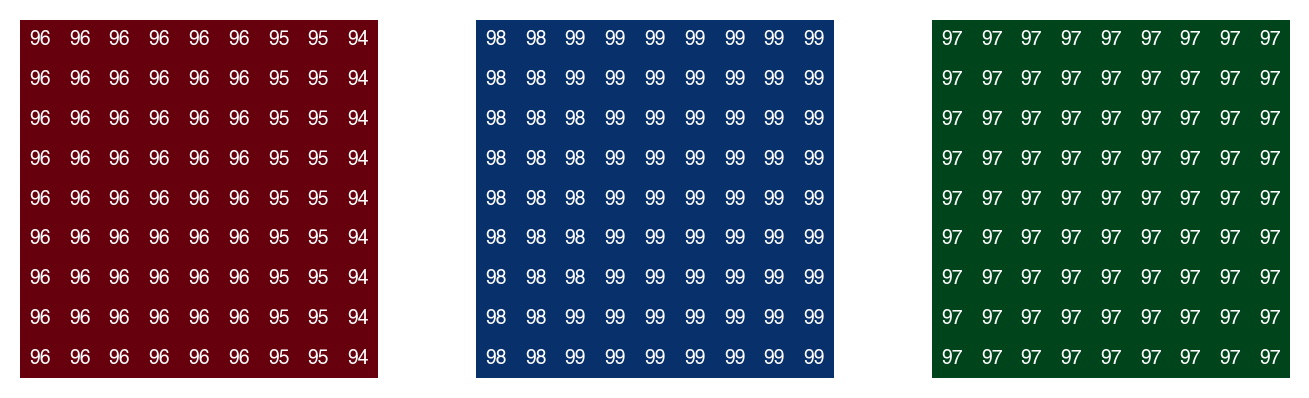

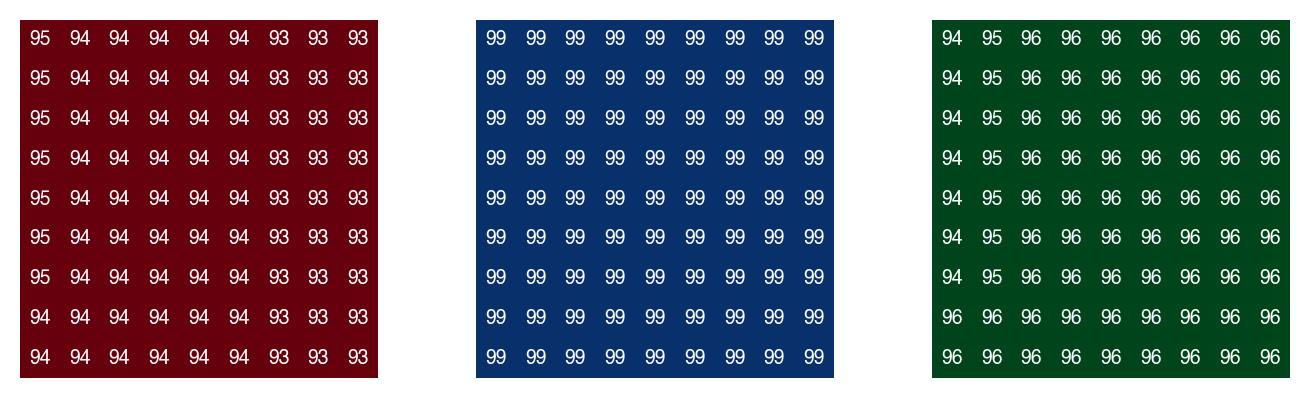

In [7]:
utils.plot_perf_heatmaps(perf_df, draw_axes=False)